<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Optimización Bayesiana: Buscar Hiperparámetros con un Modelo Sustituto 🧠
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 07
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/07%20-%20Seleccion%20de%20Modelos%20y%20Optimizacion/03_Optimizacion_Bayesiana.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno cierra el módulo (y el **Capítulo 2**) con las **Secciones 2.12.3 (*Bayesian Optimization*)** y **2.13.3 (*Bayesian Optimization*)**. En los cuadernos [02 (Random Search y GridSearch)](02_Random_Search_y_GridSearch.ipynb) cada evaluación se decidía **sin mirar las anteriores**. La **optimización bayesiana** (BO) usa **toda la historia**: ajusta un **modelo sustituto** de la función de validación y elige la siguiente configuración donde **más se espera aprender o mejorar**. Es la herramienta cuando **evaluar es caro**. Como en todo el curso: **teoría, implementación desde cero y verificación con `assert`** contra `scikit-learn`/`SciPy`.

Al terminar podrás:

1. **Formular** el ajuste de hiperparámetros como **optimización de una caja negra costosa** y describir el bucle de BO.
2. **Implementar un proceso gaussiano desde cero** (núcleo RBF, posterior en forma cerrada con **Cholesky**, verosimilitud marginal) y **verificarlo contra `GaussianProcessRegressor`** con hiperparámetros del núcleo fijos (`optimizer=None`).
3. **Implementar las funciones de adquisición** PI, **EI** (con su fórmula cerrada, **derivada y verificada** contra Monte Carlo e integración numérica) y UCB/LCB, y entender el **compromiso exploración–explotación** ($\xi$, $\kappa$).
4. **Seguir paso a paso** una optimización 1D (media, banda de incertidumbre, adquisición, siguiente punto).
5. **Aplicar un bucle de BO propio** a los hiperparámetros de un SVM y **compararlo con Random Search sobre varias semillas**, reportando con honestidad cuándo **no** gana por mucho.
6. **Conocer TPE y Optuna** como alternativas prácticas (celda opcional) y las **limitaciones** de BO (dimensión, ruido, hiperparámetros categóricos o condicionales, costo cúbico).
7. **Elegir** entre rejilla, aleatoria, reducción sucesiva y bayesiana según el problema.

> 📍 **Dónde estamos:** Módulo 07, cuaderno 4 de 4 (después de [Random Search y GridSearch](02_Random_Search_y_GridSearch.ipynb)). Este es el último cuaderno del **Capítulo 2**.

> 🔗 **Para no repetir:** validación cruzada, `GridSearchCV`, el costo de la rejilla y `cv_results_` están en el [Módulo 03, cuaderno 02](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/02_Validacion_Cruzada_y_GridSearch.ipynb); el sesgo de selección (el mejor puntaje es optimista) y la validación anidada, en el [cuaderno 01](01_Validacion_Cruzada_Avanzada.ipynb); Random Search y la reducción sucesiva, en el [cuaderno 02](02_Random_Search_y_GridSearch.ipynb). La idea de **decidir bajo incertidumbre** (explorar o explotar) ya apareció en el [Módulo 06](../06%20-%20Aprendizaje%20por%20Refuerzo/README.md) con los bandidos y el $\varepsilon$-*greedy*.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 10 (*Fine-Tuning Neural Network Hyperparameters with Optuna*): el libro usa **Optuna** para ajustar una red con PyTorch; y Cap. 9 (*Hyperparameter Tuning Guidelines*) (disponible en `Machine Learning/Libros/`; títulos verificados contra el índice del PDF).
- *Machine Learning Engineering with Python* (2.ª ed.) — **Andrew P. McMahon** (Packt, 2023). Cap. 3 (*From Model to Model Factory*), sección *Optimizing hyperparameters*: *Hyperopt* (búsqueda aleatoria, **TPE**, que el texto describe como un enfoque de optimización bayesiana, y TPE adaptativo) y *Optuna* (disponible en `Machine Learning/Libros/`; verificado contra el PDF).
- **Rasmussen, C. E. & Williams, C. K. I. (2006)**, *Gaussian Processes for Machine Learning*, MIT Press (libre en línea): Cap. 2 (regresión con procesos gaussianos) y Cap. 5 (selección de modelo por verosimilitud marginal) *(citado de memoria, verificar)*.
- **Snoek, J., Larochelle, H. & Adams, R. P. (2012)**, *Practical Bayesian optimization of machine learning algorithms*, **NeurIPS 25** *(citado de memoria, verificar)* · **Shahriari, B. et al. (2016)**, *Taking the human out of the loop: a review of Bayesian optimization*, **Proceedings of the IEEE** 104(1): 148–175 *(citado de memoria, verificar)*.
- Jones, D. R., Schonlau, M. & Welch, W. J. (1998), *Efficient global optimization of expensive black-box functions*, **Journal of Global Optimization** 13: 455–492 (origen de **EI**) · Srinivas, N. et al. (2010), *Gaussian process optimization in the bandit setting*, **ICML** (GP-UCB) *(citados de memoria, verificar)*.
- Bergstra, J., Bardenet, R., Bengio, Y. & Kégl, B. (2011), *Algorithms for hyper-parameter optimization*, **NeurIPS 24** (TPE) · Akiba, T. et al. (2019), *Optuna: a next-generation hyperparameter optimization framework*, **KDD** *(citados de memoria, verificar)*.

### 🌐 Documentación y Recursos Online:
- [scikit-learn: Gaussian Processes](https://scikit-learn.org/stable/modules/gaussian_process.html) · [`GaussianProcessRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html)
- [Optuna](https://optuna.org/) (opcional) · [BoTorch / Ax](https://botorch.org/) · [SMAC3](https://automl.github.io/SMAC3/) *(no se usan en este cuaderno)*

---
## 1. El Problema: una Caja Negra Costosa 📦💸

Buscar hiperparámetros es **optimizar una función que no conocemos**: $f(\mathbf x)$ = métrica de validación cruzada del modelo entrenado con los hiperparámetros $\mathbf x$:

$$\mathbf x^\star=\arg\max_{\mathbf x\in\mathcal X}\ f(\mathbf x).$$

Sus rasgos hacen inútiles los métodos clásicos: **no hay gradiente** (no se puede derivar el accuracy de la CV respecto a `max_depth`), **no es convexa**, **cada evaluación es costosa** (entrenar $k$ modelos: segundos, horas o días) y puede ser **ruidosa**. Con un presupuesto de $N$ evaluaciones, la rejilla y Random Search deciden **sin aprender** de las anteriores. La optimización bayesiana añade **memoria**:

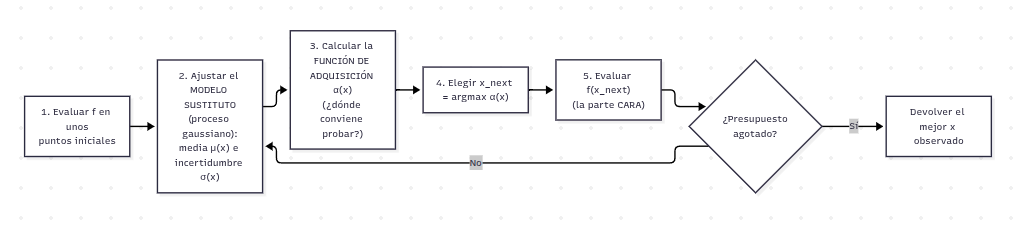

- **Modelo sustituto** (*surrogate*): una distribución sobre funciones que **cuesta poco** evaluar y que dice **qué espera** ($\mu$) y **cuánto duda** ($\sigma$) en cada $\mathbf x$. El estándar: **proceso gaussiano** (GP).
- **Función de adquisición** $\alpha(\mathbf x)$: convierte $(\mu,\sigma)$ en un número que mide **lo útil que sería evaluar** $\mathbf x$, balanceando **explotar** (donde $\mu$ es alta) y **explorar** (donde $\sigma$ es alta). Optimizarla es barato (se evalúa el sustituto, no el modelo real).

Es el mismo dilema del [Módulo 06](../06%20-%20Aprendizaje%20por%20Refuerzo/README.md) (bandidos): la diferencia es que aquí el «brazo» es un punto de un espacio **continuo** y las recompensas de brazos cercanos **están correlacionadas** (por eso sirve un GP).

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn scipy
# !pip install -q optuna   # OPCIONAL: solo para la seccion 6 (TPE / Optuna); el resto del cuaderno no lo necesita
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import sklearn
from scipy.linalg import cholesky, cho_solve, solve_triangular
from scipy.stats import norm
from scipy.integrate import quad
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
PALETA = ["#2563eb", "#dc2626", "#16a34a", "#f59e0b", "#7c3aed", "#0891b2", "#db2777", "#65a30d", "#78350f", "#475569"]
print(f"Entorno listo | numpy {np.__version__} | scipy {scipy.__version__} | scikit-learn {sklearn.__version__}")

---
## 2. El Modelo Sustituto: Proceso Gaussiano desde Cero 🕸️

### 2.1 Definición

Un **proceso gaussiano** $f\sim\mathcal{GP}(0,k)$ es una distribución sobre funciones tal que, para **cualquier** conjunto finito de puntos, los valores $(f(\mathbf x_1),\dots,f(\mathbf x_n))$ son **conjuntamente gaussianos** con covarianza $K_{ij}=k(\mathbf x_i,\mathbf x_j)$. El **núcleo** $k$ codifica el supuesto de **suavidad**; el más usado es el **RBF** (o exponencial cuadrático):

$$k(\mathbf x,\mathbf x')=\sigma_f^2\exp\!\Big(-\frac{\lVert\mathbf x-\mathbf x'\rVert^2}{2\ell^2}\Big),$$

con **escala de longitud** $\ell$ (qué tan lejos «se parecen» dos valores) y **varianza de la señal** $\sigma_f^2$. Con **ARD** hay un $\ell_j$ por dimensión.

### 2.2 El posterior en forma cerrada

Observamos $y_i=f(\mathbf x_i)+\varepsilon_i$, $\varepsilon_i\sim\mathcal N(0,\sigma_n^2)$. Como $(\mathbf y,f(\mathbf x_\ast))$ son conjuntamente gaussianos,

$$\begin{pmatrix}\mathbf y\\ f_\ast\end{pmatrix}\sim\mathcal N\!\left(\mathbf 0,\begin{pmatrix}K+\sigma_n^2I & \mathbf k_\ast\\ \mathbf k_\ast^\top & k_{\ast\ast}\end{pmatrix}\right),$$

y **condicionar** en $\mathbf y$ (propiedad de la gaussiana) da el posterior:

$$\boxed{\ \mu_\ast=\mathbf k_\ast^\top(K+\sigma_n^2I)^{-1}\mathbf y,\qquad \sigma_\ast^2=k_{\ast\ast}-\mathbf k_\ast^\top(K+\sigma_n^2I)^{-1}\mathbf k_\ast\ }$$

**Implementación numéricamente estable (Cholesky).** Nunca se invierte la matriz: se factoriza $K+\sigma_n^2I=LL^\top$ ($L$ triangular inferior), se obtiene $\boldsymbol\alpha=L^{-\top}(L^{-1}\mathbf y)$ con dos sustituciones triangulares, y $V=L^{-1}\mathbf k_\ast$ da $\sigma_\ast^2=k_{\ast\ast}-\lVert V\rVert^2$. La **log-verosimilitud marginal** (para elegir $\ell,\sigma_f,\sigma_n$ **con los datos**) es

$$\log p(\mathbf y\mid X)=-\tfrac12\mathbf y^\top\boldsymbol\alpha-\sum_i\log L_{ii}-\tfrac n2\log2\pi.$$

El costo es **$O(n^3)$** por la factorización (sección 7). Lo implementamos y **verificamos contra `GaussianProcessRegressor`** fijando los hiperparámetros del núcleo (`optimizer=None`, con `ConstantKernel(..., "fixed") * RBF(..., "fixed")`): la **media, la desviación, la covarianza posterior completa y la log-verosimilitud** deben coincidir.

In [ ]:
# ============================================================
# 2. Proceso Gaussiano DESDE CERO: nucleo RBF, posterior con Cholesky y verosimilitud marginal
# ============================================================
def kernel_rbf(A, B, ell=1.0, sf2=1.0):
    """k(x, x') = sf2 * exp(-||(x - x') / ell||^2 / 2).  A: (n, d), B: (m, d); 'ell' escalar (isotropico) o vector de d (ARD)."""
    A, B = A / ell, B / ell
    d2 = (A ** 2).sum(1)[:, None] + (B ** 2).sum(1)[None, :] - 2 * A @ B.T
    return sf2 * np.exp(-0.5 * np.maximum(d2, 0.0))                                 # max(.,0): evita -1e-16 por redondeo


class GPDesdeCero:
    """Regresion con proceso gaussiano de media cero. Posterior en forma cerrada con la factorizacion de Cholesky K + sn2 I = L L^T."""
    def __init__(self, ell=1.0, sf2=1.0, sn2=1e-6):
        self.ell, self.sf2, self.sn2 = ell, sf2, sn2

    def fit(self, X, y):
        self.X, self.y = np.asarray(X, float), np.asarray(y, float)
        K = kernel_rbf(self.X, self.X, self.ell, self.sf2) + self.sn2 * np.eye(len(self.y))
        self.L = cholesky(K, lower=True)                                            # K + sn2 I = L L^T   (O(n^3))
        self.alpha = cho_solve((self.L, True), self.y)                              # alpha = (K + sn2 I)^{-1} y   (dos sustituciones triangulares)
        return self

    def log_marginal(self):
        """log p(y | X) = -1/2 y^T alpha - sum_i log L_ii - n/2 log(2 pi)."""
        n = len(self.y)
        return -0.5 * self.y @ self.alpha - np.log(np.diag(self.L)).sum() - 0.5 * n * np.log(2 * np.pi)

    def predict(self, Xs, return_cov=False):
        """Media y desviacion (o covarianza) del proceso LATENTE f(x*) | datos."""
        Ks = kernel_rbf(self.X, np.asarray(Xs, float), self.ell, self.sf2)           # (n, m)
        mu = Ks.T @ self.alpha                                                       # mu* = K*^T (K + sn2 I)^{-1} y
        V = solve_triangular(self.L, Ks, lower=True)                                 # V = L^{-1} K*
        if return_cov:
            Kss = kernel_rbf(np.asarray(Xs, float), np.asarray(Xs, float), self.ell, self.sf2)
            return mu, Kss - V.T @ V                                                 # Sigma* = K** - V^T V
        var = self.sf2 - (V ** 2).sum(0)                                             # var(f*) = k(x*, x*) - ||V||^2
        return mu, np.sqrt(np.maximum(var, 0.0))


# --- Verificacion contra scikit-learn: hiperparametros del nucleo FIJOS (optimizer=None) ---
rng = np.random.default_rng(SEED)
for d, ell, sf2, sn2 in [(1, 0.7, 2.0, 1e-3), (2, np.array([0.5, 1.5]), 1.3, 1e-4)]:            # 1D isotropico y 2D con escalas distintas (ARD)
    X = rng.uniform(0, 3, size=(12, d)); y = np.sin(2 * X).sum(1) + 0.1 * rng.normal(size=12); Xs = rng.uniform(0, 3, size=(40, d))
    mio = GPDesdeCero(ell, sf2, sn2).fit(X, y)
    sk = GaussianProcessRegressor(kernel=ConstantKernel(sf2, "fixed") * RBF(ell, "fixed"), alpha=sn2, optimizer=None, normalize_y=False).fit(X, y)
    mu_m, sd_m = mio.predict(Xs); mu_s, sd_s = sk.predict(Xs, return_std=True)
    _, cov_m = mio.predict(Xs, return_cov=True); _, cov_s = sk.predict(Xs, return_cov=True)
    assert np.allclose(mu_m, mu_s, atol=1e-8) and np.allclose(sd_m, sd_s, atol=1e-6)         # media y desviacion identicas
    assert np.allclose(cov_m, cov_s, atol=1e-8)                                              # covarianza posterior completa identica
    assert np.isclose(mio.log_marginal(), sk.log_marginal_likelihood_value_)                 # misma verosimilitud marginal
    print(f"d = {d}: media, desviación, covarianza posterior y log-verosimilitud marginal == GaussianProcessRegressor (error máx. media = {np.abs(mu_m - mu_s).max():.1e})")

# Propiedad: sin ruido, el GP INTERPOLA (media = y en los puntos observados, desviacion ~ 0)
X1 = np.array([[0.2], [1.0], [2.1]]); y1 = np.array([0.5, -1.0, 0.3])
g = GPDesdeCero(0.6, 1.0, 1e-10).fit(X1, y1); m_obs, s_obs = g.predict(X1)
assert np.allclose(m_obs, y1, atol=1e-6) and np.all(s_obs < 1e-3)
print("Sin ruido el GP interpola los datos y la incertidumbre se anula en ellos; crece al alejarse.")

In [ ]:
# ============================================================
# 2b. Que "ve" el GP: muestras a priori, posterior y efecto de la escala de longitud
# ============================================================
f_demo = lambda x: np.sin(1.6 * x) + 0.35 * np.cos(3.2 * x)
xs = np.linspace(0, 5, 300)[:, None]
rng = np.random.default_rng(3)
X_obs = np.array([[0.1], [1.0], [1.9], [3.0], [4.9]]); y_obs = f_demo(X_obs).ravel()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
# (a) muestras del PRIOR GP(0, k) con tres escalas de longitud
for ell, col in zip((0.3, 0.8, 2.0), ("#dc2626", "#2563eb", "#16a34a")):
    L = cholesky(kernel_rbf(xs, xs, ell) + 1e-8 * np.eye(len(xs)), lower=True)
    muestras = L @ rng.normal(size=(len(xs), 2))                                     # 2 funciones muestreadas del prior por cada ell
    axes[0].plot(xs, muestras[:, 0], color=col, lw=1.6, label=f"$\\ell$ = {ell}"); axes[0].plot(xs, muestras[:, 1], color=col, lw=1.0, alpha=0.6)
axes[0].legend(fontsize=8)
axes[0].set_title("Prior: funciones suaves; $\\ell$ = escala de variación", fontweight="bold", fontsize=10); axes[0].set_xlabel("$x$"); axes[0].set_ylabel("$f(x)$")
# (b) posterior con ell = 0.8 y banda +-2 sigma
g = GPDesdeCero(0.8, 1.0, 1e-6).fit(X_obs, y_obs); mu, sd = g.predict(xs)
axes[1].plot(xs, f_demo(xs), "k--", lw=1.2, label="Función real (desconocida)")
axes[1].plot(xs, mu, color="#2563eb", lw=2, label="Media posterior"); axes[1].fill_between(xs.ravel(), mu - 2 * sd, mu + 2 * sd, color="#2563eb", alpha=0.2, label="±2 desv. (≈ 95 %)")
Lp = cholesky(g.predict(xs, return_cov=True)[1] + 1e-8 * np.eye(len(xs)), lower=True)
axes[1].plot(xs, mu[:, None] + Lp @ rng.normal(size=(len(xs), 3)), color="#2563eb", lw=0.7, alpha=0.6)
axes[1].scatter(X_obs, y_obs, color="black", zorder=5, label="Observaciones")
axes[1].set_title("Posterior con 5 observaciones ($\\ell$ = 0.8)", fontweight="bold", fontsize=10); axes[1].set_xlabel("$x$"); axes[1].legend(fontsize=7, loc="lower left")
# (c) verosimilitud marginal en funcion de ell: asi se ELIGE la escala a partir de los datos
ells = np.logspace(-1.3, 0.7, 60)
lml = [GPDesdeCero(l, 1.0, 1e-6).fit(X_obs, y_obs).log_marginal() for l in ells]
mejor = ells[int(np.argmax(lml))]
axes[2].plot(ells, lml, color="#7c3aed", lw=2); axes[2].axvline(mejor, color="#dc2626", ls="--", label=f"Máximo en $\\ell$ ≈ {mejor:.2f}")
axes[2].set_xscale("log"); axes[2].set_ylim(max(lml) - 25, max(lml) + 3); axes[2].set_xlabel("Escala de longitud $\\ell$"); axes[2].set_ylabel("$\\log p(y\\mid X)$")
axes[2].set_title("Verosimilitud marginal: elige $\\ell$ con los datos", fontweight="bold", fontsize=10); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Efecto de ell sobre la incertidumbre: con ell pequeno el GP "olvida" rapido lejos de los datos; con ell grande extrapola con confianza
for ell in (0.15, 0.8, 3.0):
    _, s = GPDesdeCero(ell, 1.0, 1e-6).fit(X_obs, y_obs).predict(np.array([[2.7]]))
    print(f"ell = {ell:>4}: desviación posterior en x = 2.7 (a 0.7 y 0.6 de las observaciones vecinas) = {s[0]:.3f}")
assert mejor > 0.2 and mejor < 3
print("Lectura: el posterior es una DISTRIBUCIÓN sobre funciones: la media es la mejor estimación y la desviación dice dónde NO sabemos (huecos y bordes). Eso es lo que explota la optimización bayesiana.")

---
##### 🛠️ Práctica 1: Elige la escala $\ell$ con la verosimilitud marginal

En la Sección 2 el posterior del proceso gaussiano dependía de la escala de longitud $\ell$ y se vio que la verosimilitud marginal ayuda a elegirla. Hazlo tú con `GPDesdeCero`, las observaciones `X_obs`, `y_obs` y la malla `xs` (definidas en la Sección 2):

1. Para $\ell\in\{0.2, 0.5, 1.0, 2.0\}$ ajusta `GPDesdeCero(ell, 1.0, 1e-6)` con `X_obs` y `y_obs`, y guarda en el diccionario `lml_prac` su `log_marginal()`.
2. Elige `ell_prac`, la escala con mayor verosimilitud marginal, y ajusta con ella `gp_prac`.
3. Predice sobre `xs` (`mu_p, sd_p = gp_prac.predict(xs)`) y encuentra `x_dudoso`: el punto de `xs` donde la desviación posterior es máxima.
4. Verifica con `assert` que la desviación en los puntos observados es casi nula (menor que 0.01) y que `x_dudoso` cae en el hueco más grande entre observaciones (entre 3.0 y 4.9).

In [ ]:
# Escribe tu código aquí

# ells_prac = [0.2, 0.5, 1.0, 2.0]
# lml_prac = {ell: GPDesdeCero(ell, 1.0, 1e-6).fit(X_obs, y_obs).log_marginal() for ell in ells_prac}
# ell_prac = max(lml_prac, key=lml_prac.get)
# gp_prac = GPDesdeCero(ell_prac, 1.0, 1e-6).fit(..., ...)
# mu_p, sd_p = gp_prac.predict(xs)
# x_dudoso = xs[np.argmax(sd_p), 0]


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
ells_prac = [0.2, 0.5, 1.0, 2.0]
lml_prac = {ell: GPDesdeCero(ell, 1.0, 1e-6).fit(X_obs, y_obs).log_marginal() for ell in ells_prac}
ell_prac = max(lml_prac, key=lml_prac.get)                  # la escala que hace mas probables los datos observados

gp_prac = GPDesdeCero(ell_prac, 1.0, 1e-6).fit(X_obs, y_obs)
mu_p, sd_p = gp_prac.predict(xs)
x_dudoso = xs[np.argmax(sd_p), 0]                           # donde el GP "duda" mas

print({k: round(float(v), 2) for k, v in lml_prac.items()})
print(f"Mejor escala: ell = {ell_prac} | punto mas incierto: x = {x_dudoso:.2f} (desviacion {sd_p.max():.2f})")

_, sd_obs = gp_prac.predict(X_obs)
assert np.all(sd_obs < 0.01)                                # sin ruido, el GP no duda donde ya midio
assert 3.0 < x_dudoso < 4.9                                 # el hueco mas grande entre observaciones
print("La incertidumbre se anula en lo observado y es maxima en el mayor hueco: ahi mirara la funcion de adquisicion.")
```
</details>

---


---
## 3. Funciones de Adquisición: ¿Dónde Evaluar a Continuación? 🎯

Sea $f^\ast=\max_i y_i$ el **mejor valor observado** (maximizamos) y $f(\mathbf x)\sim\mathcal N(\mu,\sigma^2)$ el posterior en $\mathbf x$. Sea $z=\dfrac{\mu-f^\ast-\xi}{\sigma}$. Las tres adquisiciones clásicas:

| Función | Definición | Fórmula cerrada | Comportamiento |
|---|---|---|---|
| **Probabilidad de mejora** (PI) | $P\big(f(\mathbf x)>f^\ast+\xi\big)$ | $\Phi(z)$ | Solo mide **si** mejora, no **cuánto**: con $\xi=0$ prefiere mejoras minúsculas y casi seguras |
| **Mejora esperada** (EI) | $\mathbb E\big[\max(f(\mathbf x)-f^\ast-\xi,\,0)\big]$ | $(\mu-f^\ast-\xi)\,\Phi(z)+\sigma\,\varphi(z)$ | Pondera **probabilidad × magnitud**; la opción por defecto (Jones, Schonlau y Welch, 1998) |
| **Cota de confianza** (UCB) | $\mu+\kappa\sigma$ | — | «Optimismo ante la incertidumbre»; $\kappa$ regula la exploración (GP-UCB: Srinivas *et al.*, 2010). Para **minimizar**: $\text{LCB}=\mu-\kappa\sigma$ |

**Derivación de la EI.** Sea $u=\mu-f^\ast-\xi$ y $f=\mu+\sigma\epsilon$ con $\epsilon\sim\mathcal N(0,1)$. La mejora es $\max(u+\sigma\epsilon,0)$, positiva solo si $\epsilon>-z$ con $z=u/\sigma$:

$$\text{EI}=\int_{-z}^{\infty}(u+\sigma\epsilon)\,\varphi(\epsilon)\,d\epsilon=u\,[1-\Phi(-z)]+\sigma\,\varphi(-z)=u\,\Phi(z)+\sigma\,\varphi(z),$$

usando $\int_a^\infty\epsilon\,\varphi(\epsilon)\,d\epsilon=\varphi(a)$ y la simetría de $\varphi$. Si $\sigma=0$, $\text{EI}=\max(u,0)$. **Los dos términos son explotación y exploración:** $u\,\Phi(z)$ crece con la **media**; $\sigma\,\varphi(z)$ crece con la **incertidumbre**.

**El compromiso exploración–explotación.** $\xi\ge0$ (en PI y EI) exige una mejora **mínima**: más grande, más exploración. $\kappa$ (en UCB) pesa la incertidumbre: más grande, más exploración. Valores típicos: $\xi\in[0.01,0.1]$ (con $y$ estandarizada), $\kappa\in[1,3]$.

> ⚙️ **Maximizar la adquisición** es otro problema de optimización (barato pero multimodal). En este cuaderno se evalúa sobre **un conjunto grande de candidatos** aleatorios (1 000) y se toma el mejor; en bibliotecas serias se usa un optimizador local con **múltiples arranques**.

Verificamos EI y PI contra **Monte Carlo** (2 millones de muestras) y **`scipy.integrate.quad`**, y vemos cómo cambian al mover $\xi$ y $\kappa$.

In [ ]:
# ============================================================
# 3. Funciones de adquisicion DESDE CERO (maximizacion): PI, EI y UCB/LCB, con EI verificado numericamente
# ============================================================
def prob_mejora(mu, sd, f_mejor, xi=0.0):
    """PI(x) = P(f(x) > f* + xi) = Phi((mu - f* - xi) / sigma)."""
    sd = np.maximum(sd, 1e-12)
    return norm.cdf((mu - f_mejor - xi) / sd)

def mejora_esperada(mu, sd, f_mejor, xi=0.0):
    """EI(x) = E[max(f(x) - f* - xi, 0)] = (mu - f* - xi) Phi(z) + sigma phi(z),  z = (mu - f* - xi) / sigma;  EI = 0 si sigma = 0."""
    sd = np.asarray(sd, float); imp = mu - f_mejor - xi
    z = imp / np.maximum(sd, 1e-12)
    return np.where(sd > 1e-12, imp * norm.cdf(z) + sd * norm.pdf(z), np.maximum(imp, 0.0))

def ucb(mu, sd, kappa=2.0):
    """UCB(x) = mu + kappa sigma  (maximizar).  Para MINIMIZAR se usa LCB(x) = mu - kappa sigma."""
    return mu + kappa * sd

# --- Verificacion de EI y PI: Monte Carlo (2e6 muestras) e integracion numerica con scipy.integrate.quad ---
rng = np.random.default_rng(SEED)
casos = [(0.0, 1.0, 0.5, 0.0), (1.2, 0.3, 1.0, 0.01), (-0.4, 2.0, 0.3, 0.1), (0.5, 1e-3, 0.3, 0.0), (0.0, 0.5, 2.0, 0.0)]
filas = []
for mu, sd, fb, xi in casos:
    cerrada = float(mejora_esperada(np.array(mu), np.array(sd), fb, xi))
    f_mc = rng.normal(mu, sd, 2_000_000)
    mc = np.mean(np.maximum(f_mc - fb - xi, 0.0))                                           # E[max(f - f* - xi, 0)] por Monte Carlo
    num, _ = quad(lambda f: (f - fb - xi) * norm.pdf(f, mu, sd), fb + xi, mu + 12 * sd + 1, points=[mu], limit=200) if fb + xi < mu + 12 * sd else (0.0, 0)
    pi_c, pi_mc = float(prob_mejora(np.array(mu), np.array(sd), fb, xi)), np.mean(f_mc > fb + xi)
    assert abs(cerrada - num) < 1e-7 and abs(cerrada - mc) < max(5e-3 * max(sd, 1e-3), 2e-4)   # cerrada == integral numerica == Monte Carlo
    assert abs(pi_c - pi_mc) < 2e-3
    filas.append({"mu": mu, "sigma": sd, "f*": fb, "xi": xi, "EI cerrada": cerrada, "EI integral (quad)": num, "EI Monte Carlo": mc, "PI cerrada": pi_c, "PI Monte Carlo": pi_mc})
display(pd.DataFrame(filas).round(5))
print("La fórmula cerrada de EI coincide con la integral numérica y con Monte Carlo (incluidos σ muy pequeña y f* lejos de la media).")

# Identidad entre minimizar y maximizar: LCB(mu, sigma) = -UCB(-mu, sigma)
m_, s_ = np.array([0.3, -1.0, 2.0]), np.array([0.5, 1.0, 0.1])
assert np.allclose(m_ - 2.0 * s_, -ucb(-m_, s_, 2.0))
print("Minimizar f con LCB equivale a maximizar -f con UCB: en este cuaderno SIEMPRE maximizamos (accuracy) y usamos las versiones de maximización.")

In [ ]:
# ============================================================
# 3b. Compromiso exploracion-explotacion: como cambian PI, EI y UCB con xi y kappa
# ============================================================
g = GPDesdeCero(0.8, 1.0, 1e-6).fit(X_obs, y_obs); mu, sd = g.predict(xs); f_best = y_obs.max()
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
ax = axes[0, 0]
ax.plot(xs, mu, color="#2563eb", lw=2, label="Media"); ax.fill_between(xs.ravel(), mu - 2 * sd, mu + 2 * sd, color="#2563eb", alpha=0.2)
ax.scatter(X_obs, y_obs, color="black", zorder=5, label="Observaciones"); ax.axhline(f_best, color="gray", ls=":", label="Mejor observado $f^*$")
ax.set_title("Posterior del GP", fontweight="bold", fontsize=10); ax.legend(fontsize=8)
for ax, (nombre, fn, params, etq) in zip((axes[0, 1], axes[1, 0], axes[1, 1]), [
        ("Probabilidad de mejora (PI)", lambda p: prob_mejora(mu, sd, f_best, p), (0.0, 0.05, 0.3), "$\\xi$"),
        ("Mejora esperada (EI)", lambda p: mejora_esperada(mu, sd, f_best, p), (0.0, 0.05, 0.3), "$\\xi$"),
        ("Cota superior de confianza (UCB)", lambda p: ucb(mu, sd, p), (0.5, 2.0, 5.0), "$\\kappa$")]):
    for p, col in zip(params, ("#dc2626", "#16a34a", "#7c3aed")):
        a = fn(p); ax.plot(xs, a / (a.max() if nombre.startswith("Prob") or nombre.startswith("Mejora") else 1), color=col, lw=2, label=f"{etq} = {p}")
        ax.axvline(xs[np.argmax(a), 0], color=col, ls=":", alpha=0.8)
    ax.set_title(nombre + (" (normalizada por su máximo)" if not nombre.startswith("Cota") else ""), fontweight="bold", fontsize=10); ax.legend(fontsize=8); ax.set_xlabel("$x$")
plt.tight_layout(); plt.show()

# El siguiente punto segun cada regla (lineas punteadas): PI con xi = 0 es codiciosa; xi y kappa grandes empujan a explorar
sig = lambda a: float(xs[np.argmax(a), 0])
pts = {f"PI (xi = {p})": sig(prob_mejora(mu, sd, f_best, p)) for p in (0.0, 0.05, 0.3)}
pts.update({f"EI (xi = {p})": sig(mejora_esperada(mu, sd, f_best, p)) for p in (0.0, 0.05, 0.3)})
pts.update({f"UCB (kappa = {p})": sig(ucb(mu, sd, p)) for p in (0.5, 2.0, 5.0)})
dist = lambda x: float(np.min(np.abs(X_obs.ravel() - x)))
display(pd.DataFrame({"siguiente punto": pts, "distancia al dato más cercano": {k: dist(v) for k, v in pts.items()}}).round(3))
assert dist(pts["UCB (kappa = 5.0)"]) > dist(pts["UCB (kappa = 0.5)"])                       # kappa grande -> explora lejos de lo ya visto
print("EI y PI con xi = 0 se pegan al mejor valor observado (explotación); subir xi o kappa exige más mejora/optimismo y desplaza la búsqueda a zonas inciertas (exploración).")
print("PI solo mide LA PROBABILIDAD de mejorar (ignora cuánto): con xi = 0 puede elegir mejoras minúsculas casi seguras. EI pondera la magnitud de la mejora y es la opción por defecto.")

---
##### 🛠️ Práctica 2: PI frente a EI con dos candidatos

Un GP deja dos candidatos con el mejor valor observado $f^\ast=0.82$ (con $\xi=0$): el punto **A** con $\mu=0.80$, $\sigma=0.05$ (casi seguro, pero apenas por debajo) y el punto **B** con $\mu=0.70$, $\sigma=0.20$ (peor en promedio, pero muy incierto). Usa `prob_mejora()`, `mejora_esperada()` y `norm` (ya definidos):

1. Calcula `z_A` y `z_B` con $z=(\mu-f^\ast)/\sigma$.
2. Calcula `pi_A`, `pi_B`, `ei_A` y `ei_B` con las funciones del cuaderno (pasa `np.array(...)` o escalares) y guárdalos en un `DataFrame` llamado `comparacion` con índice `["A", "B"]` y columnas `"PI"` y `"EI"`.
3. Comprueba a mano la fórmula `EI = (mu - f*) Phi(z) + sigma phi(z)` para B y guárdala en `ei_B_mano`.
4. Verifica con `assert` que **PI prefiere A**, que **EI prefiere B** y que `ei_B_mano` coincide con `ei_B`. Comenta: ¿qué término de la EI explica la diferencia?

In [ ]:
# Escribe tu código aquí

# f_star = 0.82
# z_A, z_B = (0.80 - f_star) / 0.05, ...
# pi_A, pi_B = prob_mejora(np.array(0.80), np.array(0.05), f_star), ...
# ei_A, ei_B = mejora_esperada(np.array(0.80), np.array(0.05), f_star), ...
# comparacion = pd.DataFrame({"PI": [pi_A, pi_B], "EI": [ei_A, ei_B]}, index=["A", "B"])
# ei_B_mano = (0.70 - f_star) * norm.cdf(z_B) + 0.20 * norm.pdf(z_B)


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
f_star = 0.82
z_A, z_B = (0.80 - f_star) / 0.05, (0.70 - f_star) / 0.20

pi_A, pi_B = float(prob_mejora(np.array(0.80), np.array(0.05), f_star)), float(prob_mejora(np.array(0.70), np.array(0.20), f_star))
ei_A, ei_B = float(mejora_esperada(np.array(0.80), np.array(0.05), f_star)), float(mejora_esperada(np.array(0.70), np.array(0.20), f_star))
comparacion = pd.DataFrame({"PI": [pi_A, pi_B], "EI": [ei_A, ei_B]}, index=["A", "B"])
display(comparacion.round(4))
print(f"z_A = {z_A:.2f} | z_B = {z_B:.2f}")

ei_B_mano = (0.70 - f_star) * norm.cdf(z_B) + 0.20 * norm.pdf(z_B)    # EI = (mu - f*) Phi(z) + sigma phi(z)

assert pi_A > pi_B          # PI prefiere A: es mas probable que mejore (aunque sea por muy poco)
assert ei_B > ei_A          # EI prefiere B: pondera CUANTO podria mejorar
assert np.isclose(ei_B_mano, ei_B)
print("PI solo mira la probabilidad de mejorar; la EI suma el termino de exploracion sigma * phi(z), grande en B por su incertidumbre.")
```
</details>

---


---
## 4. El Bucle Completo y una Demo 1D Paso a Paso 🔁

Armamos la clase `OptimizadorBayesiano`: en cada iteración **(1)** estandariza $y$, **(2)** ajusta el GP eligiendo $\ell$ por **verosimilitud marginal** entre una pequeña malla, **(3)** evalúa la adquisición sobre candidatos, **(4)** devuelve el mejor candidato. (Usamos $\sigma_n^2=10^{-4}$ en unidades estandarizadas: sirve de *jitter* numérico y de pequeño ruido.)

La función objetivo de la demo es una **trampa**: un pico **ancho pero más bajo** en $x=1.3$ y un pico **estrecho y más alto** en $x=3.6$, con un rizado. Los tres puntos iniciales caen lejos del pico alto: un método **solo explotador** se quedaría con el pico de $x=1.3$. En cada panel:

- **línea punteada** = función real (desconocida para el algoritmo); **línea azul y banda** = media y $\pm2\sigma$ del GP;
- **área naranja** = EI; **estrella roja** = su máximo = **el siguiente punto** que se evaluará.

Después repetimos la optimización con 100 semillas (10 evaluaciones cada una) y comparamos el **regret simple** ($f^\star$ menos el mejor valor encontrado) con **Random Search** y una **rejilla** de 10 puntos.

In [ ]:
# ============================================================
# 4. Bucle COMPLETO de optimizacion bayesiana (clase propia) y demo 1D paso a paso
# ============================================================
class OptimizadorBayesiano:
    """Maximiza una caja negra f en [0, 1]^d: GP RBF isotropico (escala elegida por verosimilitud marginal) + adquisicion EI / PI / UCB."""
    def __init__(self, adq="EI", xi=0.01, kappa=2.0, ells=(0.1, 0.2, 0.4, 0.8, 1.6), sn2=1e-4):
        self.adq, self.xi, self.kappa, self.ells, self.sn2 = adq, xi, kappa, ells, sn2

    def sugerir(self, X, y, candidatos):
        """Dado lo observado (X, y) elige el candidato que maximiza la adquisicion. Devuelve (x_siguiente, info)."""
        m, s = y.mean(), y.std() + 1e-12
        ys = (y - m) / s                                                           # y estandarizada: el GP de media cero es razonable
        gp = max((GPDesdeCero(l, 1.0, self.sn2).fit(X, ys) for l in self.ells), key=lambda g: g.log_marginal())
        mu, sd = gp.predict(candidatos)
        if self.adq == "EI": a = mejora_esperada(mu, sd, ys.max(), self.xi)
        elif self.adq == "PI": a = prob_mejora(mu, sd, ys.max(), self.xi)
        else: a = ucb(mu, sd, self.kappa)
        return candidatos[int(np.argmax(a))], {"mu": mu * s + m, "sd": sd * s, "acq": a, "ell": gp.ell}

    def optimizar(self, f, d, n_inicial, n_iter, rng, n_cand=1000):
        X = rng.uniform(size=(n_inicial, d)); y = np.array([f(x) for x in X])
        for _ in range(n_iter):
            cand = rng.uniform(size=(n_cand, d))
            x_sig, _ = self.sugerir(X, y, cand)
            X = np.vstack([X, x_sig]); y = np.append(y, f(x_sig))
        return X, y

# --- Funcion objetivo 1D (caja negra): pico ESTRECHO y alto en x = 3.6, pico ancho pero MAS BAJO en x = 1.3, mas un rizado ---
f1d = lambda x: 1.0 * np.exp(-((x - 3.6) / 0.5) ** 2) + 0.7 * np.exp(-((x - 1.3) / 0.6) ** 2) + 0.15 * np.sin(6 * x)
grid = np.linspace(0, 5, 500); x_opt, f_opt = grid[np.argmax(f1d(grid))], f1d(grid).max()
print(f"Óptimo verdadero (en la malla): f({x_opt:.2f}) = {f_opt:.3f}")

obj = lambda u: f1d(5 * u[0])                                                       # dominio unitario [0, 1] -> [0, 5]
opt = OptimizadorBayesiano("EI", xi=0.01)
X = np.array([[0.08], [0.28], [0.92]]); y = np.array([obj(x) for x in X])            # 3 puntos iniciales (ninguno cerca de x = 3.6)
cand = np.linspace(0, 1, 500)[:, None]
fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharex=True)
trayectoria = [y.max()]
for t, ax in zip(range(6), axes.ravel()):
    x_sig, info = opt.sugerir(X, y, cand)
    ax.plot(grid, f1d(grid), "k--", lw=1, label="Función real")
    ax.plot(grid, info["mu"], color="#2563eb", lw=2, label="Media del GP"); ax.fill_between(grid, info["mu"] - 2 * info["sd"], info["mu"] + 2 * info["sd"], color="#2563eb", alpha=0.18, label="±2 desv.")
    ax.scatter(5 * X[:, 0], y, color="black", zorder=5, s=35, label="Observados")
    ax2 = ax.twinx(); ax2.fill_between(grid, 0, info["acq"], color="#f59e0b", alpha=0.35, label="EI"); ax2.set_ylim(0, info["acq"].max() * 3.2); ax2.set_yticks([]); ax2.grid(False)
    ax.axvline(5 * x_sig[0], color="#dc2626", lw=1.5); ax.scatter([5 * x_sig[0]], [obj(x_sig)], marker="*", s=220, color="#dc2626", zorder=6, label="Siguiente punto")
    ax.set_title(f"Iteración {t + 1}: mejor = {y.max():.3f} | $\\ell$ = {info['ell']} (en [0, 1])", fontweight="bold", fontsize=10); ax.set_ylim(-0.9, 1.7)
    if t == 0: ax.legend(fontsize=7, loc="lower left")
    X = np.vstack([X, x_sig]); y = np.append(y, obj(x_sig)); trayectoria.append(y.max())
for ax in axes[1]: ax.set_xlabel("$x$")
plt.tight_layout(); plt.show()
print("Mejor valor tras cada iteración:", np.round(trayectoria, 3))
print("Se ve el ciclo: (1) la media y la banda resumen lo observado; (2) EI (naranja) es grande donde la media es alta O la incertidumbre es grande; (3) se evalúa el máximo de EI (estrella roja); (4) el GP se actualiza.")

# --- Comparacion honesta en 1D con 100 semillas: regret simple tras 10 evaluaciones (3 iniciales + 7), contra azar y rejilla ---
R, n_ev = 100, 10
reg_bo, reg_az = [], []
t0 = time.perf_counter()
for s in range(R):
    rng = np.random.default_rng(1000 + s)
    Xb_, yb_ = opt.optimizar(obj, 1, 3, 7, rng, n_cand=300)
    reg_bo.append(f_opt - yb_.max())
    reg_az.append(f_opt - max(obj(x) for x in rng.uniform(size=(n_ev, 1))))
reg_rej = f_opt - f1d((np.arange(n_ev) + 0.5) / n_ev * 5).max()                      # rejilla de 10 puntos equiespaciados (determinista)
display(pd.DataFrame({"mediana": [np.median(reg_bo), np.median(reg_az), reg_rej], "media": [np.mean(reg_bo), np.mean(reg_az), reg_rej],
                      "P(regret < 0.05)": [np.mean(np.array(reg_bo) < 0.05), np.mean(np.array(reg_az) < 0.05), float(reg_rej < 0.05)]},
                     index=["Optimización bayesiana (EI)", "Random Search", "Rejilla de 10 puntos"]).round(3))
print(f"(regret simple = f* − mejor encontrado, con 10 evaluaciones; {R} repeticiones en {time.perf_counter() - t0:.1f} s)")
assert np.mean(reg_bo) < np.mean(reg_az)

---
## 5. Aplicación: Ajustar `C` y `gamma` de un SVM con BO 🔧

Usamos el mismo problema que en el [cuaderno 02](02_Random_Search_y_GridSearch.ipynb): SVM RBF con `StandardScaler` sobre *Breast Cancer*, **accuracy de validación cruzada de 3 pliegues**, con los hiperparámetros en **escala logarítmica**: $\log_{10}C\in[-2,2]$ y $\log_{10}\gamma\in[-6,0]$ (se normalizan a $[0,1]^2$ para el GP). El objetivo es **determinista** (pliegues fijos), de modo que podemos tratarlo como una caja negra sin ruido.

**Diseño honesto de la comparación:**

- Presupuesto: **25 evaluaciones** (5 iniciales + 20 guiadas por BO).
- Random Search recibe **los mismos 5 puntos iniciales** (se verifica con `assert`) y 20 puntos aleatorios más.
- Se repite con **varias semillas** y se reporta **media ± desviación**; si BO no gana de forma clara, se dice.

In [ ]:
# ============================================================
# 5. Un hiperparametro real: log10 C y log10 gamma de un SVM RBF (3-fold CV) con nuestro optimizador bayesiano
# ============================================================
Xb, yb = load_breast_cancer(return_X_y=True)
pliegues = list(StratifiedKFold(3, shuffle=True, random_state=SEED).split(Xb, yb))
LIM = np.array([[-2.0, 2.0], [-6.0, 0.0]])                                          # log10 C en [-2, 2]; log10 gamma en [-6, 0]

def acc_svm(u):
    """u en [0, 1]^2 -> (log10 C, log10 gamma) -> accuracy medio de CV (objetivo DETERMINISTA: pliegues fijos)."""
    lc, lg = LIM[:, 0] + u * (LIM[:, 1] - LIM[:, 0])
    return np.mean([make_pipeline(StandardScaler(), SVC(C=10.0 ** lc, gamma=10.0 ** lg)).fit(Xb[a], yb[a]).score(Xb[b], yb[b]) for a, b in pliegues])

t0 = time.perf_counter()
rng = np.random.default_rng(7)
bo = OptimizadorBayesiano("EI", xi=0.01)
X_bo, y_bo = bo.optimizar(acc_svm, d=2, n_inicial=5, n_iter=20, rng=rng)
X_rs = np.random.default_rng(7).uniform(size=(25, 2)); y_rs = np.array([acc_svm(u) for u in X_rs])      # Random Search: mismos 5 iniciales, 20 puntos mas
assert np.allclose(X_bo[:5], X_rs[:5])                                                  # arrancan EXACTAMENTE igual (comparacion justa)
print(f"25 evaluaciones cada uno en {time.perf_counter() - t0:.1f} s | mejor BO = {y_bo.max():.4f} | mejor Random Search = {y_rs.max():.4f}")

# Posterior final del GP sobre el plano (para ver lo que "cree" el modelo sustituto)
ys_ = (y_bo - y_bo.mean()) / (y_bo.std() + 1e-12)
gp = max((GPDesdeCero(l, 1.0, 1e-4).fit(X_bo, ys_) for l in bo.ells), key=lambda g: g.log_marginal())
uu = np.linspace(0, 1, 60); U = np.array([[a, b] for a in uu for b in uu]); mu, sd = gp.predict(U)
coord = lambda P: (LIM[1, 0] + P[:, 1] * (LIM[1, 1] - LIM[1, 0]), LIM[0, 0] + P[:, 0] * (LIM[0, 1] - LIM[0, 0]))   # (log gamma, log C)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.9))
for ax, (P, yy, titulo) in zip(axes[:2], [(X_bo, y_bo, "Optimización bayesiana (EI): 25 evaluaciones"), (X_rs, y_rs, "Random Search: 25 evaluaciones")]):
    gx, gy = coord(P); sc_ = ax.scatter(gx, gy, c=yy, cmap="viridis", s=40 + 4 * np.arange(len(yy)), edgecolor="white", vmin=0.6, vmax=0.985)
    ax.scatter(*[v[np.argmax(yy)] for v in (gx, gy)], s=260, facecolors="none", edgecolors="#dc2626", lw=2.5, label=f"Mejor = {yy.max():.4f}")
    ax.set_xlim(LIM[1]); ax.set_ylim(LIM[0]); ax.set_xlabel("$\\log_{10}\\gamma$"); ax.set_ylabel("$\\log_{10} C$"); ax.set_title(titulo, fontweight="bold", fontsize=10); ax.legend(fontsize=8, loc="lower left")
    plt.colorbar(sc_, ax=ax, label="Accuracy CV")
cs = axes[2].contourf(LIM[1, 0] + uu * (LIM[1, 1] - LIM[1, 0]), LIM[0, 0] + uu * (LIM[0, 1] - LIM[0, 0]), (mu * y_bo.std() + y_bo.mean()).reshape(60, 60), 20, cmap="viridis")
gx, gy = coord(X_bo); axes[2].scatter(gx, gy, c="white", edgecolor="black", s=30); plt.colorbar(cs, ax=axes[2], label="Media posterior (accuracy)")
axes[2].set_xlabel("$\\log_{10}\\gamma$"); axes[2].set_ylabel("$\\log_{10} C$"); axes[2].set_title(f"Lo que cree el GP (ℓ = {gp.ell}; la media puede salirse de [0, 1])", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()
print("El tamaño del punto crece con el orden de evaluación: BO concentra las evaluaciones en la región buena (cresta diagonal C-gamma); el azar las reparte por todo el plano.")

In [ ]:
# ============================================================
# 5b. Comparacion HONESTA con Random Search sobre varias semillas (mismo objetivo, mismo presupuesto, mismos 5 puntos iniciales)
# ============================================================
SEMILLAS = range(6)                                                                  # sube a 30 para curvas mas finas (tarda ~ 4x mas)
N_INI, N_IT = 5, 20
t0 = time.perf_counter()
mejores_bo, mejores_rs = [], []
for s in SEMILLAS:
    Xs_, ys_s = OptimizadorBayesiano("EI", xi=0.01).optimizar(acc_svm, 2, N_INI, N_IT, np.random.default_rng(100 + s))
    Xr_ = np.random.default_rng(100 + s).uniform(size=(N_INI + N_IT, 2)); yr_ = np.array([acc_svm(u) for u in Xr_])
    mejores_bo.append(np.maximum.accumulate(ys_s)); mejores_rs.append(np.maximum.accumulate(yr_))
B_, R_ = np.array(mejores_bo), np.array(mejores_rs)
t_comp = time.perf_counter() - t0
ev = np.arange(1, N_INI + N_IT + 1)
fig, ax = plt.subplots(figsize=(10, 4.8))
for M_, col, nm in [(B_, "#2563eb", "Optimización bayesiana (EI)"), (R_, "#dc2626", "Random Search")]:
    ax.plot(ev, M_.mean(0), color=col, lw=2.2, label=nm); ax.fill_between(ev, M_.mean(0) - M_.std(0), M_.mean(0) + M_.std(0), color=col, alpha=0.15)
ax.axvline(N_INI + 0.5, color="gray", ls=":", label="Fin de los 5 puntos iniciales (idénticos)")
ax.set_xlabel("Número de evaluaciones del SVM"); ax.set_ylabel("Mejor accuracy CV encontrado"); ax.set_xlim(4, N_INI + N_IT + 0.5); ax.set_ylim(0.965, 0.982)
ax.set_title(f"Mejor puntaje vs. evaluaciones ({len(SEMILLAS)} semillas; media ± desviación)", fontweight="bold"); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

fin = pd.DataFrame({"BO": B_[:, -1], "Random": R_[:, -1]})
tabla = pd.DataFrame({f"tras {k} evaluaciones": [f"{B_[:, k - 1].mean():.4f} ± {B_[:, k - 1].std():.4f}", f"{R_[:, k - 1].mean():.4f} ± {R_[:, k - 1].std():.4f}"] for k in (10, 15, 25)},
                     index=["Optimización bayesiana", "Random Search"])
display(tabla)
gana, empata, pierde = int((fin["BO"] > fin["Random"] + 1e-12).sum()), int((np.abs(fin["BO"] - fin["Random"]) <= 1e-12).sum()), int((fin["BO"] < fin["Random"] - 1e-12).sum())
print(f"Con 25 evaluaciones: BO gana en {gana} semillas, empata en {empata} y pierde en {pierde} (de {len(SEMILLAS)}). Tiempo = {t_comp:.1f} s.")
print(f"Diferencia media (BO − Random) tras 25 evaluaciones = {(fin['BO'] - fin['Random']).mean():+.4f} accuracy (desv. estándar de la diferencia = {(fin['BO'] - fin['Random']).std():.4f}).")
print("Lectura honesta: en este problema de 2 hiperparámetros hay una región grande casi óptima, así que Random Search ya llega cerca del máximo con 25 evaluaciones y la ventaja de BO es PEQUEÑA")
print("(del orden de las décimas de punto y comparable al ruido entre semillas). La optimización bayesiana rinde más cuando cada evaluación es CARA, el presupuesto es chico y la región buena es estrecha o hay más dimensiones útiles.")
assert B_[:, -1].mean() > 0.97 and R_[:, -1].mean() > 0.97                           # ambos llegan cerca del techo del problema

---
##### 🛠️ Práctica 3: Más curiosidad en el SVM: UCB con $\kappa$ pequeño y grande

En la Sección 5 el bucle `OptimizadorBayesiano` usó EI. Pruébalo con la adquisición **UCB** y dos niveles de exploración sobre el SVM (`acc_svm()` es el objetivo, ya definido):

1. Para `kappa` en `(0.5, 5.0)` y semillas `s` en `(0, 1)`, ejecuta `OptimizadorBayesiano("UCB", kappa=kappa).optimizar(acc_svm, 2, 5, 10, np.random.default_rng(300 + s), n_cand=300)` (5 puntos iniciales + 10 guiados, con solo 300 candidatos para que sea rápido) y obtén `X_k, y_k`.
2. De cada ejecución guarda el mejor *accuracy* (`y_k.max()`) y la **dispersión** de los 10 puntos guiados: `X_k[5:].std(axis=0).mean()`.
3. Resume en un `DataFrame` llamado `res_kappa` (índice = `kappa`; columnas `"mejor accuracy"` y `"dispersión"`, promediando las dos semillas) e imprímelo.
4. Verifica con `assert` que en todas las ejecuciones el mejor valor es al menos el mejor de los 5 iniciales y que con `kappa=5.0` los puntos guiados están **más dispersos** que con `kappa=0.5`.

In [ ]:
# Escribe tu código aquí

# filas_k = []
# for kappa in (0.5, 5.0):
#     for s in (0, 1):
#         opt_k = OptimizadorBayesiano("UCB", kappa=kappa)
#         X_k, y_k = opt_k.optimizar(acc_svm, 2, 5, 10, np.random.default_rng(300 + s), n_cand=300)
#         filas_k.append({"kappa": kappa, "mejor accuracy": y_k.max(), "dispersión": X_k[5:].std(axis=0).mean(),
#                         "mejora": y_k.max() >= y_k[:5].max()})
# res_kappa = pd.DataFrame(filas_k).groupby("kappa")[["mejor accuracy", "dispersión"]].mean()


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
filas_k = []
for kappa in (0.5, 5.0):
    for s in (0, 1):
        opt_k = OptimizadorBayesiano("UCB", kappa=kappa)
        X_k, y_k = opt_k.optimizar(acc_svm, 2, 5, 10, np.random.default_rng(300 + s), n_cand=300)     # 5 iniciales + 10 guiados
        filas_k.append({"kappa": kappa,
                        "mejor accuracy": y_k.max(),
                        "dispersión": X_k[5:].std(axis=0).mean(),                          # cuanto se reparten los puntos guiados
                        "no empeora": y_k.max() >= y_k[:5].max()})
res_k = pd.DataFrame(filas_k)
res_kappa = res_k.groupby("kappa")[["mejor accuracy", "dispersión"]].mean()
display(res_kappa.round(4))

assert res_k["no empeora"].all()
assert res_kappa.loc[5.0, "dispersión"] > res_kappa.loc[0.5, "dispersión"]
print("kappa grande empuja a explorar (puntos mas repartidos); kappa pequeno explota cerca de lo ya visto. Con presupuestos tan chicos, el accuracy final es casi igual.")
```
</details>

---


---
## 6. TPE y Optuna: Alternativas Prácticas 🧰

El GP tiene dos debilidades prácticas: escala **cúbicamente** con las observaciones y maneja mal los espacios con **variables categóricas o condicionales**. El **estimador de Parzen estructurado en árbol** (TPE; Bergstra *et al.*, 2011) cambia la perspectiva: en vez de modelar $p(y\mid\mathbf x)$, modela $p(\mathbf x\mid y)$ con **dos densidades**. Se fija un cuantil $\gamma$ (p. ej. 10–25 %) de los resultados y se separan las observaciones en «buenas» ($y$ por encima del umbral $y^\ast$) y «malas»:

$$p_{\text{buena}}(\mathbf x)=p(\mathbf x\mid y>y^\ast),\qquad p_{\text{mala}}(\mathbf x)=p(\mathbf x\mid y\le y^\ast).$$

Se puede demostrar que la **EI es proporcional a $\big(\gamma+(1-\gamma)\,p_{\text{mala}}/p_{\text{buena}}\big)^{-1}$**, de modo que **maximizar $p_{\text{buena}}(\mathbf x)/p_{\text{mala}}(\mathbf x)$** equivale a maximizar la EI: se proponen puntos **frecuentes entre los buenos y raros entre los malos**. Cada densidad se estima con *kernels* (Parzen) por dimensión, lo que escala **linealmente** con las observaciones y admite **variables categóricas y condicionales** de forma natural. McMahon (Cap. 3) lo presenta dentro de *Hyperopt*.

**Optuna** (Akiba *et al.*, 2019; Géron lo usa en el Cap. 10 para ajustar una red con PyTorch) es el *framework* más usado hoy: API *define-by-run* (el espacio se define dentro de la función objetivo, con `trial.suggest_float/int/categorical`), TPE como muestreador por defecto, otros muestreadores (CMA-ES, aleatorio) y **podadores** (*pruners*) basados en *successive halving* y *Hyperband* (cuaderno 02) que **detienen** las pruebas malas a medio entrenamiento. **No es obligatorio** para este módulo: la siguiente celda lo usa **solo si está instalado** (en Google Colab hay que instalarlo con `pip install optuna`).

In [ ]:
# ============================================================
# 6. Optuna / TPE (OPCIONAL): si 'optuna' esta instalado se corre un estudio corto; si no, se avisa
# ============================================================
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAY_OPTUNA = True
except ImportError:
    HAY_OPTUNA = False

def objetivo_optuna(trial):
    lc = trial.suggest_float("log10_C", LIM[0, 0], LIM[0, 1]); lg = trial.suggest_float("log10_gamma", LIM[1, 0], LIM[1, 1])
    return acc_svm(np.array([(lc - LIM[0, 0]) / (LIM[0, 1] - LIM[0, 0]), (lg - LIM[1, 0]) / (LIM[1, 1] - LIM[1, 0])]))

if HAY_OPTUNA:
    t0 = time.perf_counter(); res = {"TPE": [], "Random": []}
    for s in range(4):
        for nombre, sampler in [("TPE", optuna.samplers.TPESampler(seed=s)), ("Random", optuna.samplers.RandomSampler(seed=s))]:
            estudio = optuna.create_study(direction="maximize", sampler=sampler); estudio.optimize(objetivo_optuna, n_trials=25)
            res[nombre].append(estudio.best_value)
    display(pd.DataFrame({"mejor accuracy CV tras 25 pruebas (media ± desv., 4 semillas)": [f"{np.mean(v):.4f} ± {np.std(v):.4f}" for v in res.values()]}, index=list(res)))
    print(f"Optuna {optuna.__version__}: 25 pruebas × 4 semillas × 2 muestreadores en {time.perf_counter() - t0:.1f} s. Mejores parámetros del último estudio de Random: {estudio.best_params}")
    print("TPE (Bergstra et al., 2011) es el muestreador por defecto de Optuna; con presupuestos tan pequeños su ventaja sobre el azar es modesta, igual que la de nuestro GP.")
else:
    print("La librería 'optuna' NO está instalada en este entorno: se omite esta celda (el resto del cuaderno no la necesita).")
    print("Para probarla: descomenta '# !pip install -q optuna' en la primera celda (en Google Colab no viene preinstalada) y vuelve a ejecutar.")
    print("Esquema de uso: study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=0)); study.optimize(objetivo, n_trials=25); study.best_params")

---
## 7. Limitaciones: Cuándo la Optimización Bayesiana Decepciona ⚠️

| Limitación | Qué pasa | Qué hacer |
|---|---|---|
| **Costo cúbico del GP** | Cada iteración refactoriza una matriz $n\times n$: $O(n^3)$ en tiempo y $O(n^2)$ en memoria | Pocas evaluaciones (la regla de uso de BO); GP dispersos; modelos de árboles (TPE, SMAC) |
| **Dimensión alta** | El GP necesita muchos datos para aprender un espacio grande; con $d\gtrsim20$ la ventaja sobre Random Search se desvanece | Reducir dimensiones (fijar hiperparámetros poco importantes), BO con subespacios, o Random Search |
| **Ruido en la evaluación** | El mejor valor observado es **optimista** (maldición del ganador); EI puede sobreexplotar un punto con suerte | Modelar el ruido ($\sigma_n^2>0$), re-evaluar al ganador, validación **anidada** (cuaderno 01) |
| **Categóricos / condicionales** | `kernel='rbf'` activa `gamma`; `kernel='linear'` no. El núcleo RBF supone un espacio continuo y euclídeo | Núcleos especiales, *one-hot*, o TPE/SMAC (árboles) que manejan estas estructuras |
| **Elección de la adquisición** | Maximizarla es multimodal; los candidatos aleatorios dejan huecos en dimensión alta | Multi-arranque con optimizador local; muestrear alrededor del mejor |
| **Paralelismo** | BO es **secuencial** por naturaleza (la siguiente decisión depende de la anterior) | Lotes (*batch BO*) con penalización local o *fantasy points*; o Random Search/halving, que paralelizan trivialmente |

Medimos tres de ellas: el costo cúbico (tiempo de la factorización de Cholesky), la **ventaja que se encoge con la dimensión** (problema suave $f(\mathbf x)=-\lVert\mathbf x-\mathbf c\rVert^2$ con 30 evaluaciones y 15 semillas) y el **optimismo del mejor valor observado** bajo ruido.

In [ ]:
# ============================================================
# 7. Limitaciones: costo cubico del GP, dimension alta y ruido en la evaluacion
# ============================================================
# (a) Costo cubico: tiempo de la factorizacion de Cholesky (el paso dominante) segun el numero de observaciones n
ns = np.array([1000, 2000, 3000, 4000])
tiempos = []
for n in ns:
    A = np.random.default_rng(0).normal(size=(n, 5)); K = kernel_rbf(A, A, 1.5) + 1e-4 * np.eye(n)
    mejor_t = np.inf
    for _ in range(3):                                                              # minimo de 3 repeticiones: robusto al ruido del sistema
        t0 = time.perf_counter(); cholesky(K, lower=True); mejor_t = min(mejor_t, time.perf_counter() - t0)
    tiempos.append(mejor_t)
pend = np.polyfit(np.log(ns), np.log(tiempos), 1)[0]                                  # pendiente log-log del tiempo frente a n
print("n =", ns.tolist(), "-> Cholesky (s):", np.round(tiempos, 4).tolist(), f"| pendiente log-log ≈ {pend:.2f} (teoría: 3; el BLAS multihilo y la caché la suavizan a veces)")
assert 1.8 < pend < 3.5 and tiempos[-1] > tiempos[0]
print("Cada iteración reajusta el GP: O(n³) con n evaluaciones previas. Para n ≲ 1000 es irrelevante frente a una evaluación cara, pero ya no lo es con decenas de miles de puntos (se usan aproximaciones: GP dispersos, árboles como TPE/SMAC).")

# (b) Dimension: ventaja de BO sobre Random Search en un problema suave f(x) = -||x - c||^2 con 30 evaluaciones y 15 semillas
t0 = time.perf_counter()
filas = []
for d in (2, 5, 10, 20):
    rng_c = np.random.default_rng(0); reg_b, reg_r = [], []
    for s in range(15):
        c = rng_c.uniform(0.2, 0.8, d); f = lambda x: -np.sum((x - c) ** 2)
        _, yb_ = OptimizadorBayesiano("EI", xi=0.01).optimizar(f, d, 5, 25, np.random.default_rng(s))
        yr_ = np.array([f(x) for x in np.random.default_rng(s).uniform(size=(30, d))])
        reg_b.append(-yb_.max()); reg_r.append(-yr_.max())                            # regret simple: el optimo vale 0
    filas.append({"dimensión d": d, "regret BO": np.mean(reg_b), "regret Random": np.mean(reg_r), "cociente Random / BO": np.mean(reg_r) / np.mean(reg_b)})
dim = pd.DataFrame(filas).set_index("dimensión d"); display(dim.round(4))
print(f"(tiempo = {time.perf_counter() - t0:.1f} s)")
assert dim["cociente Random / BO"].iloc[0] > dim["cociente Random / BO"].iloc[-1] > 1.0        # la ventaja DECRECE con d, pero sigue siendo > 1 en este problema suave
print("Con 30 evaluaciones la ventaja de BO cae al subir la dimensión (el GP necesita muchos datos para aprender un espacio grande); en la práctica se recomienda BO hasta ~20 dimensiones, y menos con presupuestos chicos.")

# (c) Ruido: con evaluaciones ruidosas, el mejor valor OBSERVADO es optimista (maldicion del ganador)
rng = np.random.default_rng(SEED)
sigma_ruido, n_pts, T = 0.10, 20, 2000
xs_r = rng.uniform(0, 5, size=(T, n_pts)); verdad = f1d(xs_r); observado = verdad + rng.normal(0, sigma_ruido, size=verdad.shape)
elegido = observado.argmax(axis=1); optimismo = (observado.max(axis=1) - verdad[np.arange(T), elegido]).mean()
print(f"Ruido σ = {sigma_ruido}: el mejor puntaje observado sobreestima el valor REAL del punto elegido en {optimismo:.3f} en promedio.")
assert optimismo > 0.02
print("Con objetivos ruidosos (CV con partición aleatoria, entrenamiento estocástico) hay que modelar el ruido (sn2 > 0 en el GP), re-evaluar al ganador y estimar el rendimiento con validación ANIDADA (cuaderno 01).")
print("Otras limitaciones: hiperparámetros CATEGÓRICOS y CONDICIONALES (p. ej. 'gamma' solo existe si kernel='rbf') exigen núcleos especiales o modelos de árboles (TPE, SMAC); y el óptimo de la adquisición también es un problema de optimización.")

---
## 8. Recomendaciones Prácticas: ¿Rejilla, Aleatoria o Bayesiana? 🧭

| Situación | Elige | Razón |
|---|---|---|
| 1–2 hiperparámetros, ajustes baratos | **Rejilla** fina (o aleatoria) | Cubre todo, es interpretable (mapa de calor) y la sofisticación no se paga |
| Varios hiperparámetros, ajustes **baratos** (segundos) | **Random Search** | Simple, paralelizable, robusto; la ventaja de BO se diluye si puedes pagar cientos de evaluaciones |
| Ajustes **caros** (minutos u horas), pocos hiperparámetros **continuos** (≲ 10–20) | **Optimización bayesiana** (GP o TPE) | Cada evaluación evitada ahorra mucho; la historia se aprovecha |
| Espacio con **categóricos y condicionales** o muchos hiperparámetros | **TPE (Optuna / Hyperopt)** o SMAC | Árboles y densidades manejan la estructura; escala linealmente |
| Entrenamientos **largos** que se pueden evaluar parcialmente (épocas, árboles) | **Successive halving / Hyperband**, o TPE + *pruner* | Descartan pronto a las malas configuraciones |
| Mucho cómputo en **paralelo** | Random Search / halving (o BO por lotes) | BO es secuencial |
| **Siempre** | Semillas fijas, varias repeticiones, **prueba sellada o validación anidada** | El «mejor puntaje» de cualquier búsqueda es **optimista**: reporta el rendimiento con datos que no participaron |

> 🔑 **Regla de oro:** empieza por lo simple (**Random Search con `loguniform`**), mide cuánto cuesta una evaluación y cuántas puedes pagar; pasa a BO cuando evaluar sea **realmente caro**. Y recuerda: **la mejor optimización de hiperparámetros no arregla datos malos ni una mala partición** (cuaderno 01).

> 🎓 **Cierre del Capítulo 2:** recorriste el **aprendizaje no supervisado** (*clustering*, Módulo 04), la **reducción de dimensionalidad** (Módulo 05), el **aprendizaje por refuerzo** (Módulo 06) y ahora la **evaluación y selección de modelos** (Módulo 07). El [README del módulo](README.md) incluye **Lecturas Complementarias** para profundizar en todo el capítulo.

---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Caja negra costosa** | $\max_{\mathbf x}f(\mathbf x)$ sin gradiente, no convexa, cara y ruidosa. BO = **modelo sustituto + función de adquisición + bucle** que reutiliza toda la historia |
| **Proceso gaussiano** | Posterior cerrado $\mu_\ast=\mathbf k_\ast^\top(K+\sigma_n^2I)^{-1}\mathbf y$ y $\sigma_\ast^2=k_{\ast\ast}-\mathbf k_\ast^\top(K+\sigma_n^2I)^{-1}\mathbf k_\ast$ vía **Cholesky**; **idéntico** a `GaussianProcessRegressor` (media, desviación, covarianza y log-verosimilitud) con núcleo fijo |
| **Escala $\ell$** | Controla la suavidad; se elige por **verosimilitud marginal** |
| **Adquisición** | **EI** $=(\mu-f^\ast-\xi)\Phi(z)+\sigma\varphi(z)$ (derivada y verificada con Monte Carlo y `quad`); **PI** $=\Phi(z)$; **UCB** $=\mu+\kappa\sigma$ (LCB para minimizar) |
| **Exploración–explotación** | $\xi$ y $\kappa$ grandes → explorar; PI con $\xi=0$ es codiciosa. EI es el estándar |
| **Resultado honesto** | En el SVM de 2 hiperparámetros, BO y Random Search quedaron **muy cerca**; la ventaja de BO es pequeña con presupuestos chicos y regiones buenas amplias |
| **TPE / Optuna** | TPE maximiza $p_{\text{buena}}/p_{\text{mala}}$ (≈ EI) con densidades; maneja categóricos/condicionales y escala linealmente. Optuna es opcional aquí |
| **Limitaciones** | Costo $O(n^3)$ (pendiente log-log medida ≈ 2.5–3); la ventaja **se encoge con la dimensión**; el ruido produce optimismo; BO es secuencial |
| **Elección** | Rejilla (1–2 dim., barato) → Random Search (varias dim., barato) → BO/TPE (caro, pocos continuos) → halving (entrenamientos largos). **Siempre** validar con datos intactos |

> 🎓 **Siguiente paso:** continúa con el Taller Práctico del módulo (`../homeworks/07_Seleccion_Modelos_Optimizacion_Hands_On.ipynb`, que se publica aparte) y revisa las **Lecturas Complementarias** del [README](README.md).

---
### 🧠 Autoevaluación

1. Explica con tus palabras por qué **Random Search** no usa lo aprendido en las evaluaciones anteriores y qué ganaría un método que sí lo hiciera. ¿En qué situación esa ganancia **no** compensa la complejidad de implementarlo?
2. Con el posterior de un GP en un punto $x$: $\mu=0.80$, $\sigma=0.05$, y $f^\ast=0.82$ ($\xi=0$). Calcula $z$ y evalúa cualitativamente PI y EI. Luego repite con $\mu=0.70$, $\sigma=0.20$. ¿Cuál punto prefiere cada adquisición y por qué?
3. Deduce la fórmula cerrada de la EI a partir de la definición $\mathbb E[\max(f-f^\ast-\xi,0)]$ con $f\sim\mathcal N(\mu,\sigma^2)$. ¿Qué papel juega cada uno de los dos sumandos (explotación y exploración)?
4. ¿Qué ocurre con el posterior del GP si $\ell$ es **muy pequeño**? ¿Y si es **muy grande**? ¿Cómo ayuda la verosimilitud marginal a elegirlo y qué riesgo corre con **pocos** datos?
5. En la comparación con Random Search sobre el SVM, BO ganó por muy poco (o empató). Da **tres** razones por las que eso es esperable en ese problema y **describe un experimento** (con tu propio criterio de presupuesto, dimensión y costo por evaluación) en el que esperarías una ventaja mucho mayor.
6. Tu espacio de búsqueda tiene `kernel` (categórico), `gamma` (solo si el núcleo es RBF), `degree` (solo si es polinómico) y `C`. ¿Por qué un GP con núcleo RBF estándar lo maneja mal y qué alternativa usarías? ¿Qué papel tiene la validación **anidada** al reportar el rendimiento final?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>